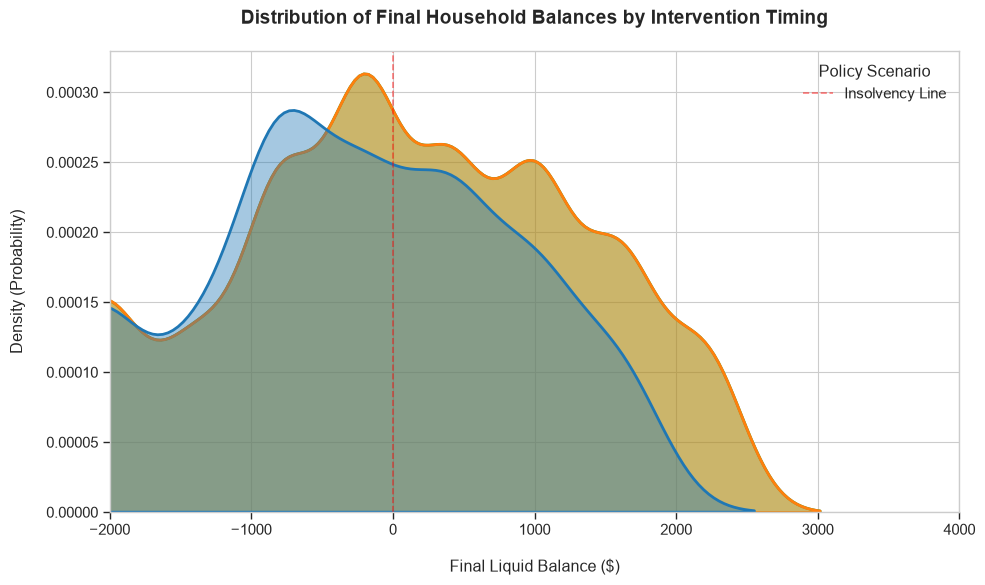

In [ ]:
import sys
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect the notebook to your src directory
sys.path.append(os.path.abspath('..'))

from src.model.household import Household
from src.model.choice_set import Action, ChoiceSet
from src.model.simulation import Simulation
from src.model.intervention import Intervention

# Set up the visualization style for an academic paper
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# 1. Define the parameters
universal_actions = [
    Action("Pay in Full", 0.0, 0.1),
    Action("Min Payment", 50.0, 0.2),
    Action("Refinance", 10.0, 0.8),
    Action("Payday Loan", 150.0, 0.1)
]
choice_set = ChoiceSet(universal_actions)

def new_household():
    return Household(1000.0, 5000.0, 1200.0, 1500.0, 0.6)

iterations = 2000
results_data = []

# 2. Run a lightweight Monte Carlo loop for the visualization
for i in range(iterations):
    seed = random.randint(0, 100000)
    
    # Control
    sim_c = Simulation(new_household(), choice_set, 12, 0.3, -600.0, random_seed=seed)
    sim_c.run()
    results_data.append({"Scenario": "Control (None)", "Final Balance": sim_c.household.balance})
    
    # Early Intervention
    sim_e = Simulation(new_household(), choice_set, 12, 0.3, -600.0, 
                       Intervention("Early", 600.0, 2), random_seed=seed)
    sim_e.run()
    results_data.append({"Scenario": "Early (Month 2)", "Final Balance": sim_e.household.balance})
    
    # Late Intervention
    sim_l = Simulation(new_household(), choice_set, 12, 0.3, -600.0, 
                       Intervention("Late", 600.0, 8), random_seed=seed)
    sim_l.run()
    results_data.append({"Scenario": "Late (Month 8)", "Final Balance": sim_l.household.balance})

df = pd.DataFrame(results_data)

# 3. Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Final Balance", hue="Scenario", fill=True, common_norm=False, alpha=0.4, linewidth=2)

plt.title("Distribution of Final Household Balances by Intervention Timing", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Final Liquid Balance ($)", labelpad=15)
plt.ylabel("Density (Probability)", labelpad=15)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Insolvency Line')
plt.xlim(-2000, 4000)
plt.legend(title="Policy Scenario")
plt.tight_layout()
plt.show()

The Path-Dependence of Financial Scarcity: Timing and Cognitive Capacity

This Kernel Density Estimation (KDE) plot visualizes the severe path-dependence inherent in household financial shocks, demonstrating that the timing of a liquidity transfer is just as economically significant as its magnitude. In this dynamic model, unexpected expenses do not merely reduce a household's liquid balance; they consume a finite cognitive resource defined as bandwidth or attention.

When households face unmitigated shocks (as seen in the Control and Late Intervention distributions), the immediate necessity of managing the financial shortfall depletes their cognitive capacity. As attention drops below critical thresholds, their financial choice-set artificially contracts. The agent loses the capacity to execute complex, low-cost optimization strategies—such as debt refinancing—and is systematically forced into cognitively "cheap" but financially punitive alternatives, such as payday loans or minimum standard payments.

The Early Intervention curve illustrates a distinct rightward shift toward long-term solvency. By injecting liquidity in Month 2, the policy protects the household's cognitive bandwidth before the choice-set contracts. The agent retains access to optimal financial actions, preventing the accumulation of high-penalty debt. Conversely, the Late Intervention fails to shift the distribution meaningfully. By Month 8, the identical $600 transfer is entirely absorbed by the compounding costs of the sub-optimal behaviors triggered during the periods of cognitive depletion. Ultimately, this mathematically illustrates that financial scarcity becomes irreversible not precisely when liquidity runs out, but when cognitive constraint permanently locks a household into a punitive cost structure.

Two curved waves showing household bank accounts after a year of shocks. This chart proves path-dependence. Two people can start with the exact same financial health, but the one who got help early recovers, while the one who got help late remains trapped in insolvency. Timing matters more than the money itself.